In [41]:
import pandas as pd
import numpy as np
import json
import os

print("All libraries imported successfully!")

# Check if data files exist
files = [
    '../data/docs.json',
    '../data/queries_train.json',
    '../data/queries_test.json',
    '../data/qgts_train.json'
    # if does not work use below
    # '/data/docs.json',
    # '/data/queries_train.json',
    # '/data/queries_test.json',
    # '/data/qgts_train.json'
]

print("\nchecking files...")

for file_path in files:
    if os.path.exists(file_path):
        print(f"found: {file_path}")
    else:
        print(f" MISSING: {file_path} (check your folder structure)")

All libraries imported successfully!

checking files...
found: ../data/docs.json
found: ../data/queries_train.json
found: ../data/queries_test.json
found: ../data/qgts_train.json


### 1. Data Loading & Inspection:
- docs.json is a library of $`questions`$ posted online that we want to search through.(creating DataFrames)

In [42]:
# load documents
dataframe_docs=pd.read_json("../data/docs.json")
print(len(dataframe_docs))

# load train queries
dataframe_train=pd.read_json("../data/queries_train.json")
print(len(dataframe_train))

# load test queries
dataframe_test=pd.read_json("../data/queries_test.json")
print(len(dataframe_test))

# load qgts->queries ground truths -> it is a dictionnary not a list. 
# so we load it as a raw dictionnary
with open("../data/qgts_train.json","r") as f:
    ground_truth=json.load(f)
print(len(ground_truth))


216041
327
141
327


In [43]:
# top 5 rows of docs.json using jupyter 'display' to veiw as a nice table
display(dataframe_docs.head())

# display train queries
display(dataframe_train.head())

# show one answer from the qgts(queries ground truths)
# code below: from ground_truth dictionnary, it extract the first key into a list.
first_query_id = list(ground_truth.keys())[0]
print(f"for Query ID '{first_query_id}' :")
display(ground_truth[first_query_id])

,id,text,title,tags,category
0,6970cbf2-ffff-4c7b-b73d-52524000c232_145427,I try to install Complete MiKTeX 2.9 But there...,MikTex Download Failure - toptesi.tar.lzma,[miktex],tex
1,667220d0-66be-4059-ae60-b9df15d285f7_77850,I'm trying to get a launcher working for the W...,Launcher for a Python program that requires ex...,"[gnome3, python, path, cd]",unix
2,e5608645-f23d-4cf4-bda6-46071510ebb0_84546,Its unclear as to whether this trait means tha...,"How does the ""Double damage in combat"" trait w...",[ftl-faster-than-light],gaming
3,367fcce1-2ed8-4a95-81e4-77e30c1a37eb_154499,I am writing a thesis with specific margin req...,"Compiling with ""latex"" instead of ""pdflatex"" c...","[margins, geometry]",tex
4,75fcda1e-9b8e-4d95-bbd9-770dd6f011cc_41849,I always see job positions for web companies f...,Machine Learning Web Jobs,"[job-definition, artificial-intelligence]",programmers


,id,text,title,tags,category
0,961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878,Want to try reformatting Damaged SD Card,,"[linux, development]",android
1,4008ed78-e66e-4d89-9c3b-c79bd1cf6fc9_366,"Convince grep to output all lines, not just th...",,"[shell, virtualization, storage, cluster]",unix
2,d5a95b09-e8ea-44dd-993d-347ed418e1f1_15138,How can I automatically reject some types of c...,,"[linux, development]",android
3,3e66798a-b7fd-41b5-8bc0-33b3d7ce2aca_177487,Left and right braces on different lines of align,,"[tikz-pgf, horizontal-alignment, tikz-trees]",tex
4,f5f944d2-277a-481d-ab09-612890402ded_137489,How do you get the purple shark fin?,,[skyrim],gaming


for Query ID '961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878' :


{'total_relevant_docs': 4,
 'relevant_doc_ids': [{'doc_id': '135f5fdb-bcba-40b8-b90d-823617f1e805_21141',
   'relevance': 1},
  {'doc_id': 'd0609dab-fbf2-4838-be6a-05e76b291258_30322', 'relevance': 1},
  {'doc_id': 'cccd8617-6417-44a5-9f67-d4b7001b7165_47263', 'relevance': 1},
  {'doc_id': 'b953c47d-7a5f-4541-bf66-c8c645f179e2_44205', 'relevance': 1}],
 'category': 'android'}

Why relevance is usually 1

In this dataset:

- 1 = relevant

- 0 = not listed (implicitly irrelevant)

Some datasets use:

- 0, 1, 2 (graded relevance)

- but here it’s binary relevance

---

### STEP 2 — Data Exploration & Statistics (MANDATORY)

**Objective**: Before building a system, we must understand the "shape" of our data. How long are the documents? How many answers does a typical question have?

Why do this?

- to describe the dataset.

- and If documents are huge (10,000 words), we treat them differently than if they are tweets (10 words).


1. Compute Length Statistics
We need to count how many words are in each document and query.

    **Intuition**: We will create new columns text_len (number of words) just to measure them.

In [ ]:
def count_words(text):
    if not text:
        return 0  # handle empty text
    return len(text.split())


# 1. Calculate lengths for docs.json
docs_text_lengths = []
for text in dataframe_docs["text"]:
    docs_text_lengths.append(count_words(text))

dataframe_docs["docs_text_lengths"] = docs_text_lengths


# 2. Calculate lengths for Train Queries
train_text_lengths = []
for text in dataframe_train["text"]:
    train_text_lengths.append(count_words(text))

dataframe_train["train_text_lengths"]=train_text_lengths


# Print Summary Statistics using "describe"
# describe() is a pandas summary function that computes common statistics for a column or DataFrame.
print("--- docs text length stats (Word Count) ---")
print(dataframe_docs["docs_text_lengths"].describe())

print("\n--- train text length Stats (Word Count) ---")
print(dataframe_train["train_text_lengths"].describe())

--- Document Length Stats (Word Count) ---
count    216041.000000
mean        126.323499
std         146.610625
min           0.000000
25%          54.000000
50%          89.000000
75%         150.000000
max        5249.000000
Name: docs_text_lengths, dtype: float64

--- Query Length Stats (Word Count) ---
count    327.000000
mean       8.400612
std        3.591281
min        2.000000
25%        6.000000
50%        8.000000
75%       10.000000
max       26.000000
Name: train_text_lengths, dtype: float64


```
** min is 0, we have empty documents! (This is a data quality issue).**
```


![no_text_problem screen shot of data](img/no_text_problem.png)


2. Visualize the Distributions (Plots)


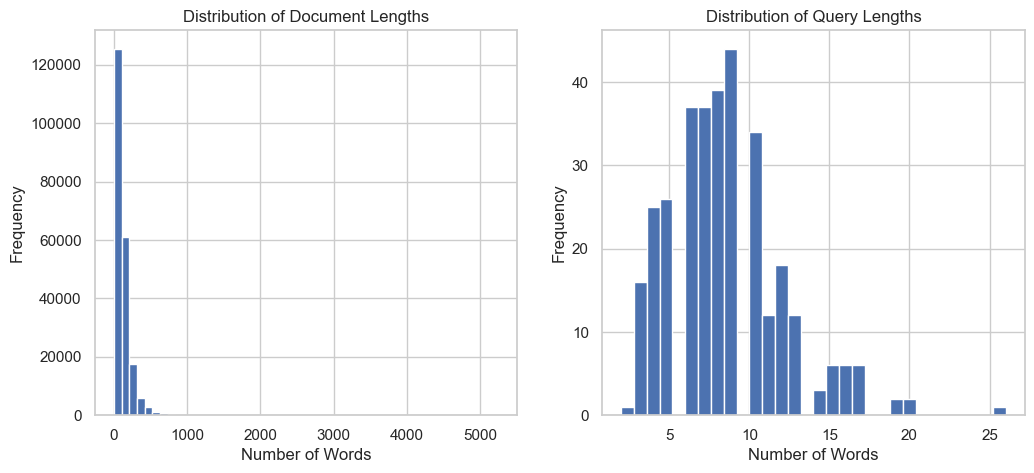

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: docs Lengths
ax[0].hist(dataframe_docs["docs_text_lengths"], bins=50)
ax[0].set_title("Distribution of Document Lengths")
ax[0].set_xlabel("Number of Words")
ax[0].set_ylabel("Frequency")

# Plot 2: training Query Lengths
ax[1].hist(dataframe_train["train_text_lengths"], bins=30)
ax[1].set_title("Distribution of Query Lengths")
ax[1].set_xlabel("Number of Words")
ax[1].set_ylabel("Frequency")

plt.show()

The dataset has short, clean queries and highly variable, long-tailed documents, which is normal — but we must handle empty and very long documents explicitly.

3. Analyze Relevance (The "ground truth")

    We need to know: How many correct answers does a typical query have?

    - If every query has only 1 correct answer, it's a specific fact-finding task.

    - If queries have 50 correct answers, it's a broad topic search.

--- Relevance Statistics ---
Total Queries with answers: 327
Average relevant docs per query: 3.00
Max relevant docs per query: 3
Min relevant docs per query: 3


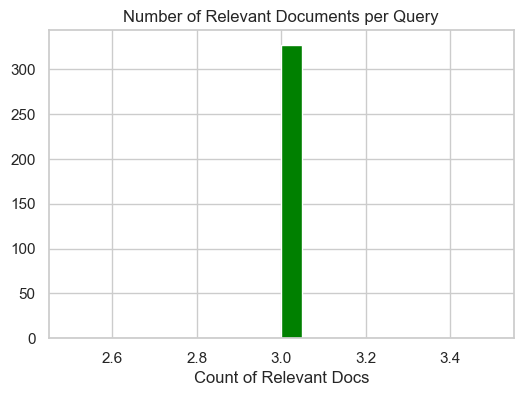

In [46]:
# Count relevant docs per query
# ground_truth is {query_id: {doc_id: 1, doc_id: 1...}}
# We want to count the keys in the inner dictionary
rel_counts = [len(docs) for docs in ground_truth.values()]

print("--- Relevance Statistics ---")
print(f"Total Queries with answers: {len(rel_counts)}")
print(f"Average relevant docs per query: {np.mean(rel_counts):.2f}")
print(f"Max relevant docs per query: {np.max(rel_counts)}")
print(f"Min relevant docs per query: {np.min(rel_counts)}")

# Plot this distribution
plt.figure(figsize=(6, 4))
plt.hist(rel_counts, bins=20, color='green')
plt.title('Number of Relevant Documents per Query')
plt.xlabel('Count of Relevant Docs')
plt.show()

4. Analyze Tags (Categories)

    What topics are we dealing with?

--- Top 10 Most Common Tags ---
[('linux', 8299), ('tikz-pgf', 8041), ('bash', 4217), ('tables', 4070), ('minecraft', 3674), ('beamer', 3341), ('fonts', 3194), ('math-mode', 2888), ('shell', 2850), ('ubuntu', 2833)]


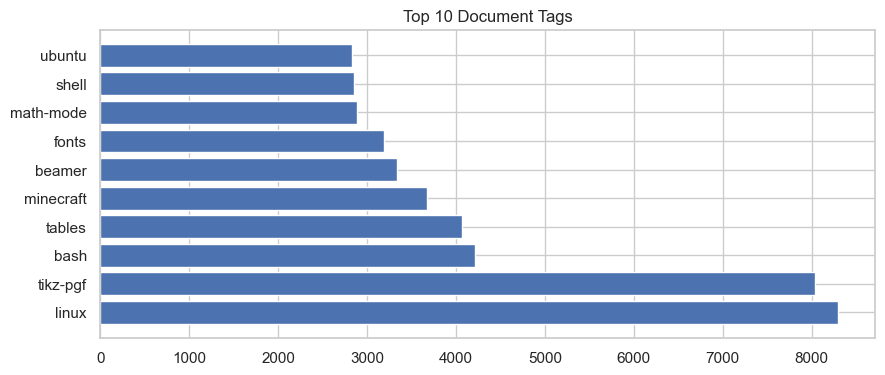

In [48]:
from collections import Counter

# flat the list of lists: [['tech'], ['science', 'tech']] -> ['tech', 'science', 'tech']
all_tags = [tag for tags_list in dataframe_docs["tags"] for tag in tags_list]
tag_counts = Counter(all_tags)

# Show top 10 tags
print("--- Top 10 Most Common Tags ---")
print(tag_counts.most_common(10))

# Plot top 10
top_tags = pd.DataFrame(tag_counts.most_common(10), columns=["Tag", "Count"])
plt.figure(figsize=(10, 4))
plt.barh(top_tags["Tag"], top_tags["Count"])
plt.title("Top 10 Document Tags")
plt.show()

Strictly 3 Answers: Every single query in the training set has exactly 3 relevant documents. It means the competition organizers curated this dataset very strictly.

Short Queries vs. Long Docs: Queries are tiny (~8 words). Documents are medium (~126 words).

Topic: "Linux" is the top tag. This is a technical support dataset (likely from a forum like StackExchange).